# Project Title: IPL 2022 Match Analysis

##### The objective of this project is to explore IPL 2022 match data and identify trends related to team performance, toss decisions, batting, bowling, venues, and match outcomes.

In [1]:
# Importing required libraries 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('IPL.csv') 

In [3]:
df

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22


### Dataset Overview

#### What are the dimensions of the Dataset?

In [4]:
df.shape

(74, 20)

In [5]:
print(f"your rowa are {df.shape[0]} and your columns are {df.shape[1]}")

your rowa are 74 and your columns are 20


#### What are the First Five Records?

In [6]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


#### What are the Last five records?

In [7]:
df.tail()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22
73,74,"May 29,2022","Narendra Modi Stadium, Ahmedabad",Gujarat,Rajasthan,Final,Rajasthan,Bat,130,9,133,3,Gujarat,Wickets,7,Hardik Pandya,Shubman Gill,45,Hardik Pandya,3--17


#### What information does the Dataset Contain?

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

#### What are the statistical summaries of numerical coumns?

In [9]:
df.describe()

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,margin,highscore
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,37.500000,171.121622,6.135135,158.540541,6.175676,16.972973,71.716216
std,21.505813,29.048355,2.222699,29.299207,2.639832,19.651047,20.705052
min,1.000000,68.000000,0.000000,72.000000,1.000000,2.000000,28.000000
25%,19.250000,154.250000,5.000000,142.750000,4.000000,5.250000,57.000000
50%,37.500000,169.500000,6.000000,160.000000,6.000000,8.000000,68.000000
75%,55.750000,192.750000,8.000000,176.000000,8.000000,18.000000,87.750000
max,74.000000,222.000000,10.000000,211.000000,10.000000,91.000000,140.000000


#### What are the statistical summaries of categorical columns?

In [10]:
df.describe(include='object')

,date,venue,team1,team2,stage,toss_winner,toss_decision,match_winner,won_by,player_of_the_match,top_scorer,best_bowling,best_bowling_figure
count,74,74,74,74,74,74,74,74,74,74,74,74,74
unique,62,6,9,9,3,10,2,10,2,56,37,42,51
top,"March 27,2022","Wankhede Stadium, Mumbai",Banglore,Rajasthan,Group,Gujarat,Field,Gujarat,Wickets,Kuldeep Yadav,Jos Buttler,Yuzvendra Chahal,3--22
freq,2,21,16,17,70,10,59,12,37,4,7,5,5


#### Are there any missing values?

In [11]:
df.isnull()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
70,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
71,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
72,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

#### Are there any duplicate records?

In [13]:
df.duplicated().sum()

np.int64(0)

#### How many unique values are present in each column?

In [14]:
df.nunique()

match_id               74
date                   62
venue                   6
team1                   9
team2                   9
stage                   3
toss_winner            10
toss_decision           2
first_ings_score       55
first_ings_wkts        10
second_ings_score      50
second_ings_wkts       10
match_winner           10
won_by                  2
margin                 31
player_of_the_match    56
top_scorer             37
highscore              46
best_bowling           42
best_bowling_figure    51
dtype: int64

### Team Performance Analysis

#### Which team won the most matches

In [15]:
df['match_winner'].value_counts()

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

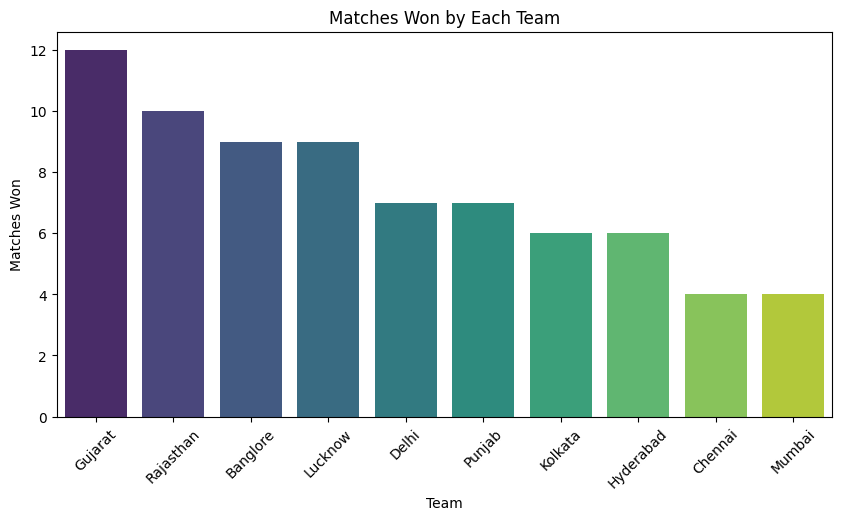

In [16]:
wins = df['match_winner'].value_counts()
plt.figure(figsize=(10,5))
sns.barplot(x=wins.index, y=wins.values, palette = 'viridis')

plt.title("Matches Won by Each Team")
plt.xlabel("Team")
plt.ylabel("Matches Won")
plt.xticks(rotation=45)

plt.savefig("images/matches_won.png", dpi=300)
plt.show()

#### Which team lost the most matches

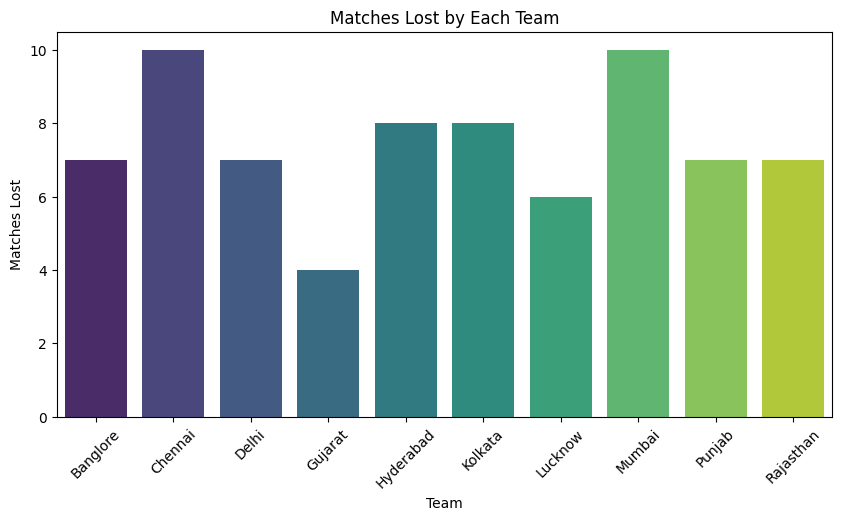

In [17]:
teams = pd.concat([df['team1'], df['team2']]).value_counts()

wins = df['match_winner'].value_counts()

losses = teams - wins

plt.figure(figsize=(10,5))
sns.barplot(x=losses.index, y=losses.values, palette= 'viridis')

plt.title("Matches Lost by Each Team")
plt.xlabel("Team")
plt.ylabel("Matches Lost")
plt.xticks(rotation=45)

plt.savefig("images/matches_lost.png", dpi=300)
plt.show()

#### What is the win percentage of each team?

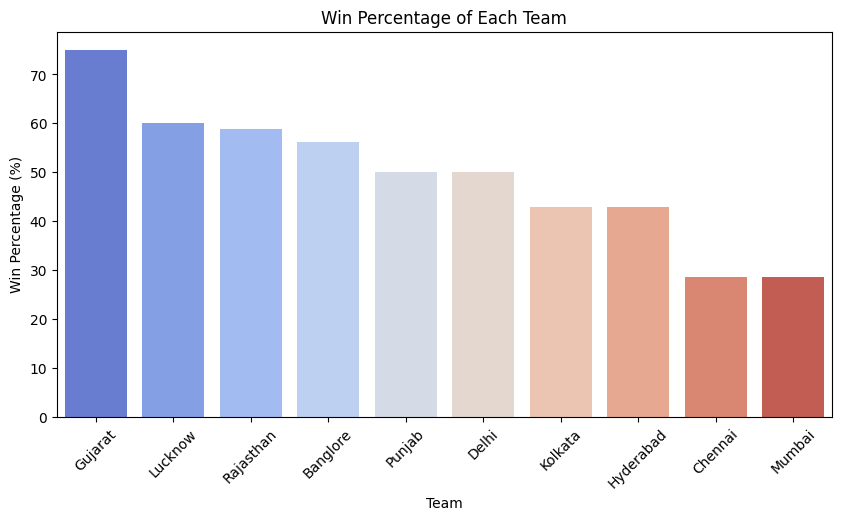

In [18]:
matches = pd.concat([df['team1'], df['team2']]).value_counts()

wins = df['match_winner'].value_counts()

win_percentage = ((wins / matches) * 100).sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=win_percentage.index, y=win_percentage.values, palette = 'coolwarm')

plt.title("Win Percentage of Each Team")
plt.xlabel("Team")
plt.ylabel("Win Percentage (%)")
plt.xticks(rotation=45)

plt.savefig("images/win_percentage.png", dpi=300)
plt.show()

#### Which team had the biggest victory?

In [19]:
biggest = df[df['margin'] == df['margin'].max()]
biggest[['match_winner','won_by','margin']]

,match_winner,won_by,margin
54,Chennai,Runs,91


#### Which team had the closest victory?

In [20]:
closest = df[df['margin'] == df['margin'].min()]
closest[['match_winner', 'won_by', 'margin']]

,match_winner,won_by,margin
65,Lucknow,Runs,2


### Toss Analysis

#### Which team won the most tosses?

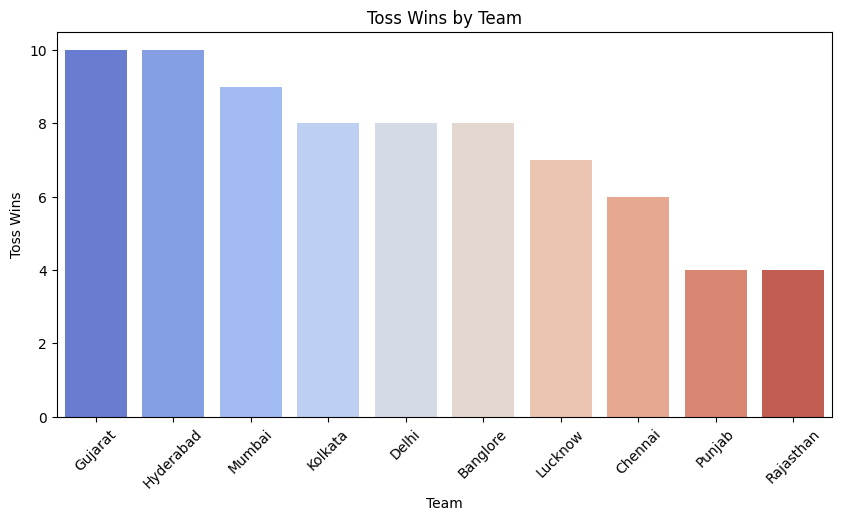

In [21]:
toss = df['toss_winner'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=toss.index, y=toss.values, palette = 'coolwarm')

plt.title("Toss Wins by Team")
plt.xlabel("Team")
plt.ylabel("Toss Wins")
plt.xticks(rotation=45)

plt.savefig("images/toss_wins.png", dpi=300)
plt.show()

#### Which toss decision was most common?

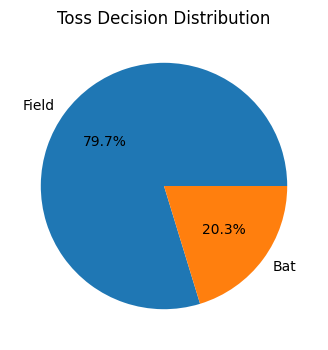

In [22]:
decision = df['toss_decision'].value_counts()

plt.figure(figsize=(4,4))

plt.pie(decision.values, labels=decision.index, autopct="%1.1f%%")

plt.title("Toss Decision Distribution")

plt.savefig("images/toss_decision.png", dpi=300)
plt.show()

#### Does winning the toss increase the chance of winning the match?

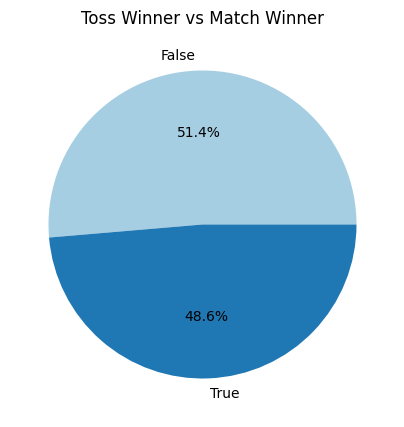

In [23]:
toss_match = (df['toss_winner'] == df['match_winner']).value_counts()

paired_palette = plt.get_cmap('Paired').colors
plt.figure(figsize=(5,5))
plt.pie(toss_match.values,labels=toss_match.index, autopct= '%1.1f%%', colors=paired_palette)

plt.title("Toss Winner vs Match Winner")

plt.savefig("images/toss_match.png", dpi=300)
plt.show()



#### Which team benefited the most from winning the toss?

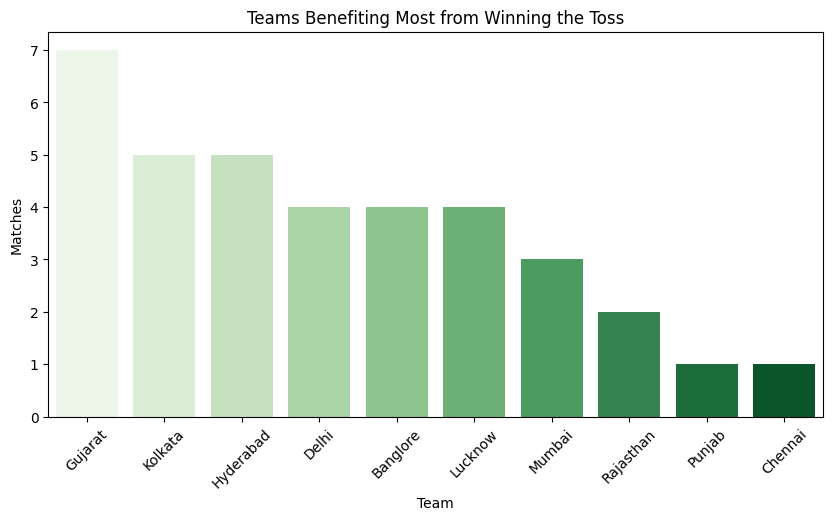

In [24]:
benefit = df[df['toss_winner'] == df['match_winner']]['match_winner'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=benefit.index, y=benefit.values, palette = 'Greens')

plt.title("Teams Benefiting Most from Winning the Toss")
plt.xlabel("Team")
plt.ylabel("Matches")
plt.xticks(rotation=45)

plt.savefig("images/toss_benefit.png", dpi=300, bbox_inches="tight")
plt.show()

### Venue Analysis

#### Which venue hosted the most matches?

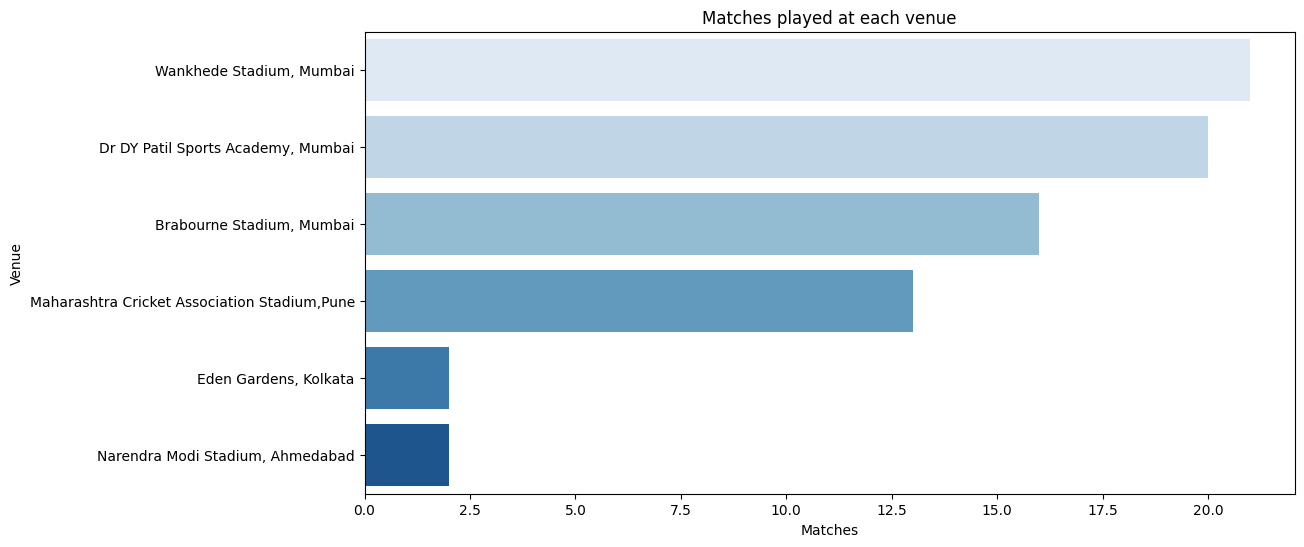

In [25]:
venue = df['venue'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=venue.values, y = venue.index, palette = 'Blues')

plt.title('Matches played at each venue')
plt.xlabel('Matches')
plt.ylabel('Venue')
plt.savefig('images/venues.png', dpi=300)
plt.show()

#### Which venue favored chasing teams?

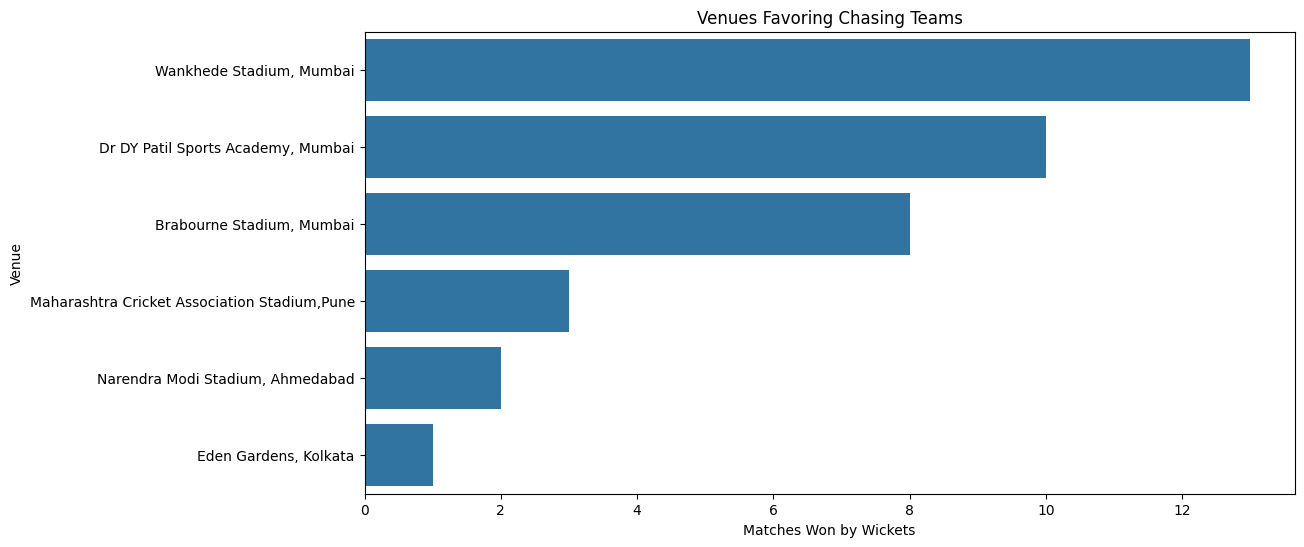

In [26]:
chasing = df[df['won_by'] == 'Wickets']['venue'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=chasing.values, y=chasing.index)

plt.title("Venues Favoring Chasing Teams")
plt.xlabel("Matches Won by Wickets")
plt.ylabel("Venue")

plt.savefig("images/chasing_venues.png", dpi=300)
plt.show()

#### Which venue produced the highest victory margins?

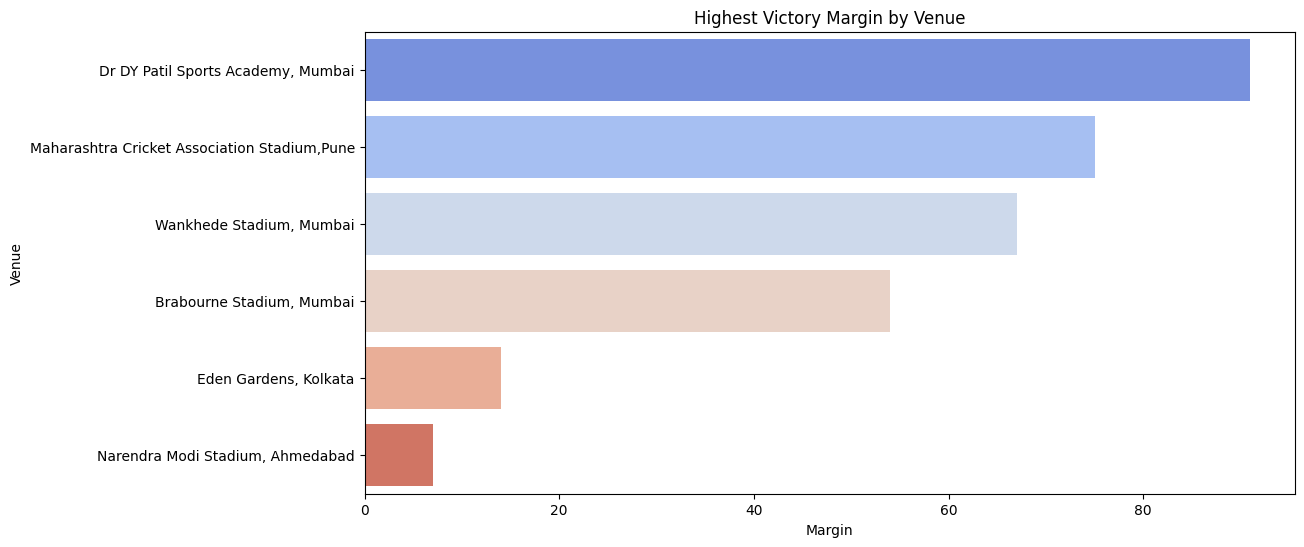

In [35]:
margin = df.groupby('venue')['margin'].max().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=margin.values, y=margin.index, palette = 'coolwarm')

plt.title("Highest Victory Margin by Venue")
plt.xlabel("Margin")
plt.ylabel("Venue")

plt.savefig("images/venue_margin.png", dpi=300)
plt.show()

### Player Performance

#### Who won the most Player of the Match awards?

In [38]:
df['player_of_the_match'].value_counts()

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Umesh Yadav          2
Wanindu Hasaranga    2
Avesh Khan           2
Dinesh Karthik       2
Quinton de Kock      2
Shubman Gill         2
Yuzvendra Chahal     2
Hardik Pandya        2
Rahul Tripathi       2
K L Rahul            2
Umran Malik          2
David Miller         2
Jasprit Bumrah       2
Odean Smith          1
Mohammed Shami       1
Sanju Samson         1
Evin Lewis           1
Lockie Ferguson      1
Liam Livingstone     1
Pat Cummins          1
Abhishek Sharma      1
Anuj Rawat           1
Kane Williamson      1
Shivam Dube          1
Mayank Agarwal       1
Faf du Plessis       1
Mukesh Choudhary     1
Rashid Khan          1
Marco Jansen         1
Shikhar Dhawan       1
Riyan Parag          1
Krunal Pandya        1
Rahul Tewatia        1
Suruakumar Yadav     1
Mohsin Khan          1
Ruturaj Gaikwad      1
Rinku Singh          1
Kagiso Rabada        1
Harshal Patel        1
David Warner         1
Tim David     

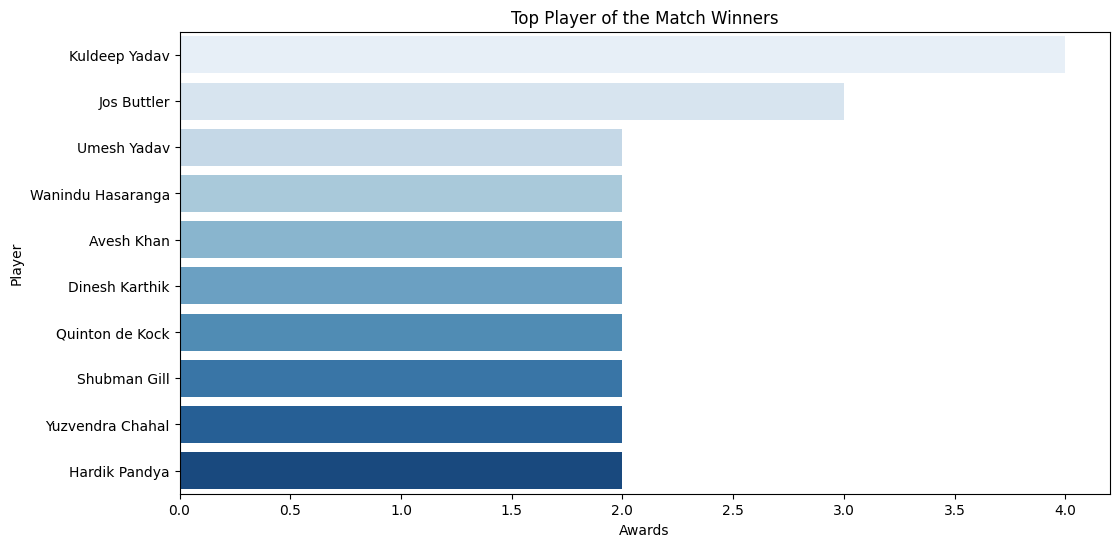

In [47]:
Player_of_match_awards = df['player_of_the_match'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x = Player_of_match_awards.values, y = Player_of_match_awards.index, palette = 'Blues')

plt.title("Top Player of the Match Winners")
plt.xlabel("Awards")
plt.ylabel("Player")

plt.savefig("images/player_of_match.png", dpi=300)
plt.show()

#### Which batter scored the most runs?

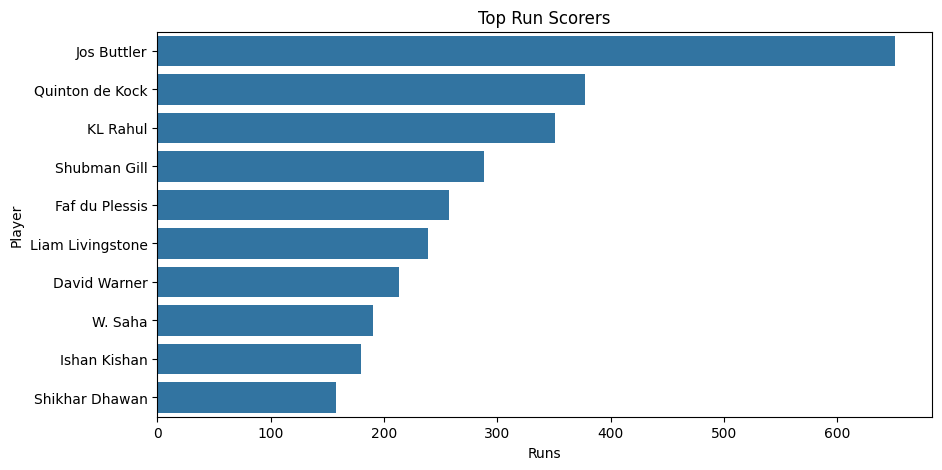

In [50]:
runs = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=runs.values, y=runs.index)

plt.title("Top Run Scorers")
plt.xlabel("Runs")
plt.ylabel("Player")

plt.savefig("images/top_runs.png", dpi=300)
plt.show()

#### Which bowler took the most wickets?

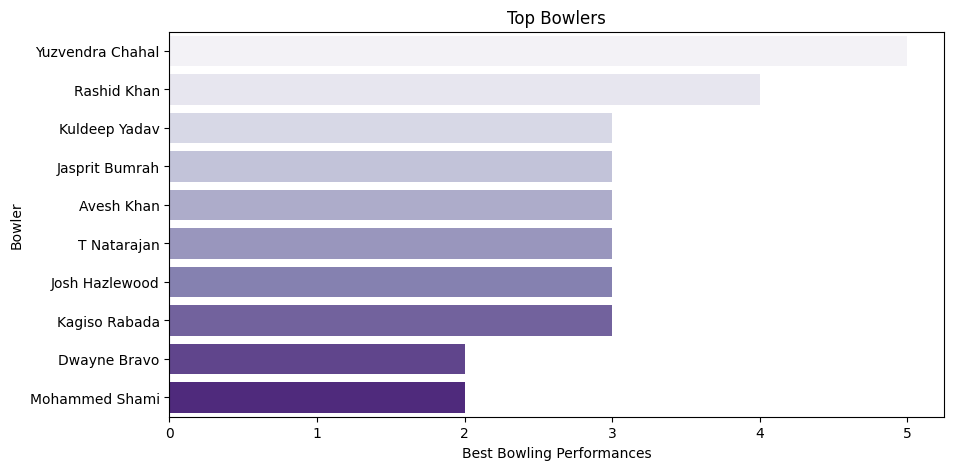

In [54]:
wickets = df['best_bowling'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=wickets.values, y=wickets.index, palette='Purples')

plt.title("Top Bowlers")
plt.xlabel("Best Bowling Performances")
plt.ylabel("Bowler")

plt.savefig("images/top_bowlers.png", dpi=300)
plt.show()

### Match Analysis

#### What was the highest winning margin?

In [64]:
df[['match_winner','won_by','margin']].sort_values(by='margin', ascending=False).head()

,match_winner,won_by,margin
54,Chennai,Runs,91
52,Lucknow,Runs,75
53,Banglore,Runs,67
56,Gujarat,Runs,62
4,Rajasthan,Runs,61


#### Were matches won more often by runs or wickets?

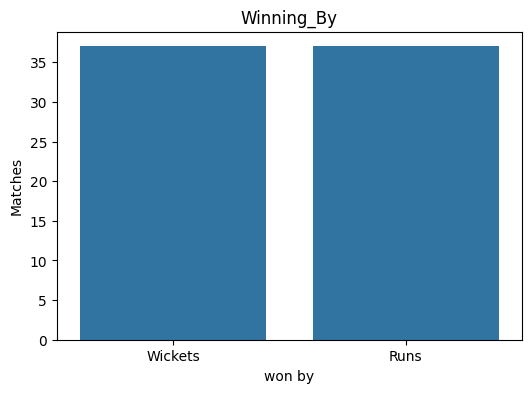

In [69]:
Matches_won_by = df['won_by'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x = Matches_won_by.index, y = Matches_won_by.values)
plt.title('Winning_By')
plt.xlabel('won by')
plt.ylabel('Matches')

plt.savefig("images/winning_method.png", dpi=300)
plt.show()

#### What was the distribution of victory margins?

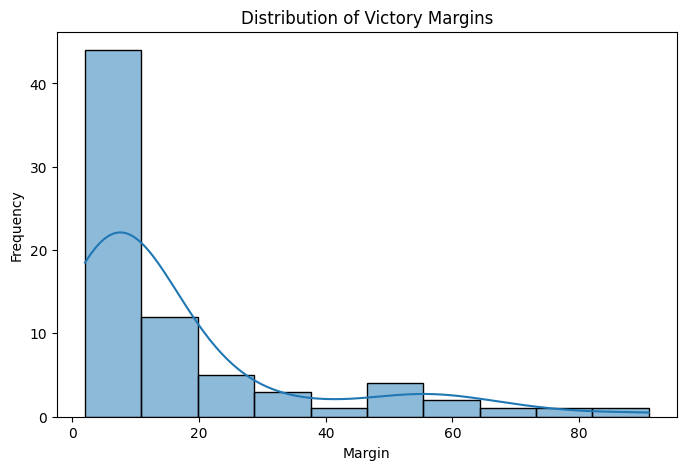

In [72]:
plt.figure(figsize=(8,5))

sns.histplot(df['margin'], bins=10, kde=True)

plt.title("Distribution of Victory Margins")
plt.xlabel("Margin")
plt.ylabel("Frequency")

plt.savefig("images/victory_margin_distribution.png", dpi=300)
plt.show()

#### Average Winning Margin(Runs)

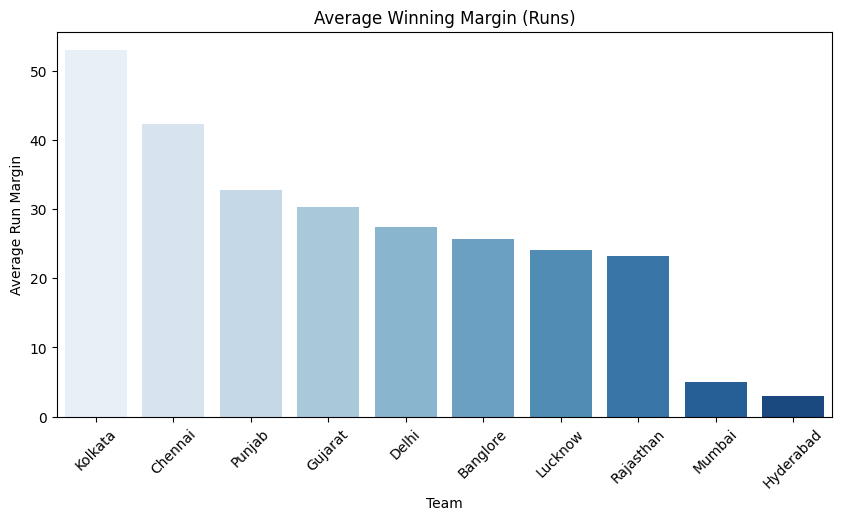

In [79]:
run_margin = df[df['won_by'] == 'Runs'].groupby('match_winner')['margin'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=run_margin.index, y=run_margin.values, palette = 'Blues')

plt.title("Average Winning Margin (Runs)")
plt.xlabel("Team")
plt.ylabel("Average Run Margin")

plt.xticks(rotation=45)

plt.savefig("images/avg_run_margin.png", dpi=300)
plt.show()

In [80]:
#### Average Winning Margin(Wickets)

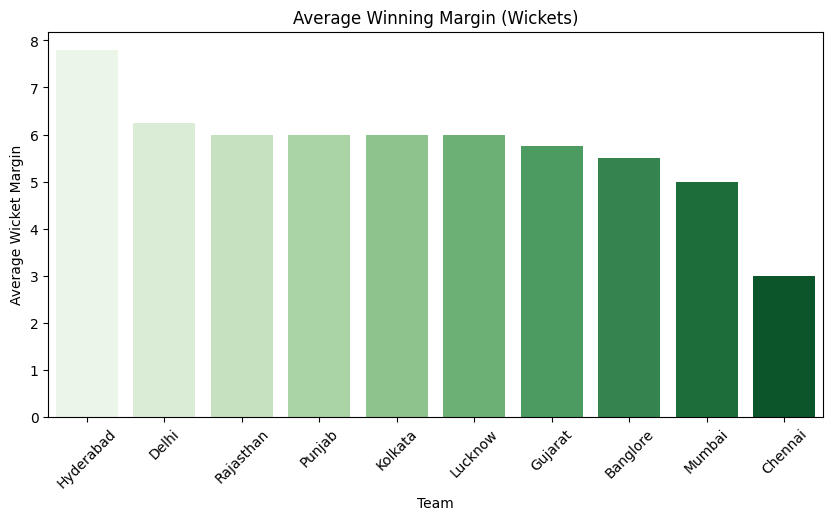

In [82]:
wicket_margin = df[df['won_by'] == 'Wickets'].groupby('match_winner')['margin'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=wicket_margin.index, y=wicket_margin.values, palette = "Greens")

plt.title("Average Winning Margin (Wickets)")
plt.xlabel("Team")
plt.ylabel("Average Wicket Margin")

plt.xticks(rotation=45)

plt.savefig("images/avg_wicket_margin.png", dpi=300)
plt.show()